<a href="https://colab.research.google.com/github/vigji/python-cimec-2025/blob/mila/practicals/Practicals_3.3_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#because we're in google colab, you need to install the required libraries each time you run the script. If running locally, you can create an environment with these libraries.
!pip install openneuro-py pybids nibabel nilearn --quiet
!pip install -q gdown
!pip install bids --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.6/214.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 13.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import nibabel as nb
import bids
from openneuro import download

import matplotlib.pyplot as plt

from pathlib import Path

# Practicals 3.3

## Practicals 3.3.1

In [3]:
# access the files that I have uploaded on google drive
!gdown 1RY_79IneZoH2X2pMO2TJ3EpGX2vC6ssR -O sub-001_task-rest_bold.nii.gz
!gdown 1s-sr72U8w3apP0fAC_Jf5sfjPJG6w2y- -O sub-001_task-rest_boldmask.nii.gz
!gdown 1Q10ezQSmKjAEnUy2WcmDescAobh2-LkT -O sub-001_T2w.nii.gz
!gdown 1cDGvxdBm9XL844ZInM4CQXpImcKWB60f -O sub-001_task-rest_proc-cleaned_bold.nii.gz

bold_img = nb.load("sub-001_task-rest_bold.nii.gz") #load the file as nifti
bold_mask = nb.load("sub-001_task-rest_boldmask.nii.gz")
anat_img = nb.load("sub-001_T2w.nii.gz")
bold_img_clean = nb.load("sub-001_task-rest_proc-cleaned_bold.nii.gz")



Downloading...
From (original): https://drive.google.com/uc?id=1RY_79IneZoH2X2pMO2TJ3EpGX2vC6ssR
From (redirected): https://drive.google.com/uc?id=1RY_79IneZoH2X2pMO2TJ3EpGX2vC6ssR&confirm=t&uuid=12426633-bde9-44e5-901d-d49dccc0dcea
To: /content/sub-001_task-rest_bold.nii.gz
100% 122M/122M [00:02<00:00, 45.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1s-sr72U8w3apP0fAC_Jf5sfjPJG6w2y-
To: /content/sub-001_task-rest_boldmask.nii.gz
100% 4.72k/4.72k [00:00<00:00, 8.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Q10ezQSmKjAEnUy2WcmDescAobh2-LkT
To: /content/sub-001_T2w.nii.gz
100% 2.19M/2.19M [00:00<00:00, 32.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1cDGvxdBm9XL844ZInM4CQXpImcKWB60f
From (redirected): https://drive.google.com/uc?id=1cDGvxdBm9XL844ZInM4CQXpImcKWB60f&confirm=t&uuid=1fc8734f-3ea3-444f-a16b-bd1264b739b8
To: /content/sub-001_task-rest_proc-cleaned_bold.nii.gz
100% 73.2M/73.2M [00:00<00:00, 74.2MB/s]


In [4]:
# what is the resolution of the BOLD and anat scans? (hint: print the header of the image and check the affine)
# which one has the higher resolution?
# do these two scans share the same origin/location within the MRI scanner?
print(bold_img.affine)
print(anat_img.affine)

[[ 0.2         0.          0.         -6.26999998]
 [ 0.          0.2         0.         -8.18999958]
 [ 0.          0.          0.2        -4.19999981]
 [ 0.          0.          0.          1.        ]]
[[ 0.15000001  0.          0.         -6.26999998]
 [ 0.          0.15000001  0.         -8.18999958]
 [ 0.          0.          0.15000001 -4.19999981]
 [ 0.          0.          0.          1.        ]]


In [5]:
# extract the array of data from img
data = bold_img.get_fdata()


In [6]:

# rescale the image so that all values are between 0 and 1
data_rescaled = (data - np.min(data)) / (np.max(data) - np.min(data))

# save the output as a nifti in the same folder as the original image, except indicate in the name that it has be rescaled
nb.save(nb.Nifti1Image(data_rescaled, bold_img.affine, bold_img.header),"sub-001_task-rest_proc-rescaled_bold.nii.gz")

## 3.3.2

In [7]:
from nilearn import image as nli
from nilearn import plotting

# now load all 4 images with nilearn
bold_img = nli.load_img("sub-001_task-rest_bold.nii.gz")
bold_mask =nli.load_img("sub-001_task-rest_boldmask.nii.gz")
anat_img = nli.load_img("sub-001_T2w.nii.gz")
bold_img_clean = nli.load_img("sub-001_task-rest_proc-cleaned_bold.nii.gz")

/tmp/ipython-input-8-2008311180.py:2: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  plotting.view_img(anat_img, bg_img = False)



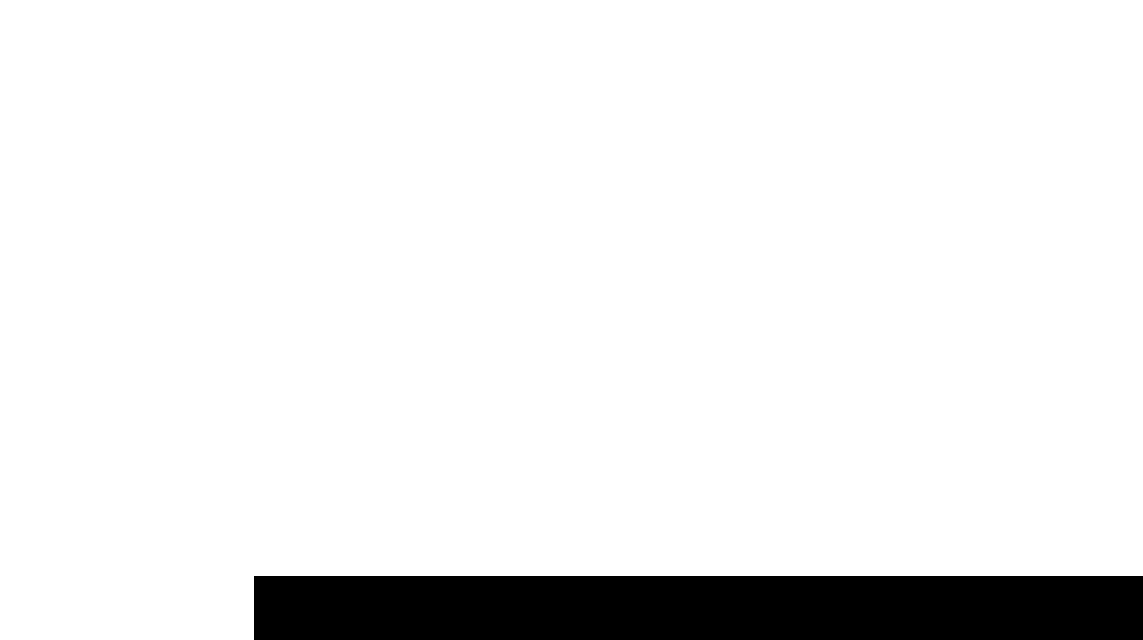
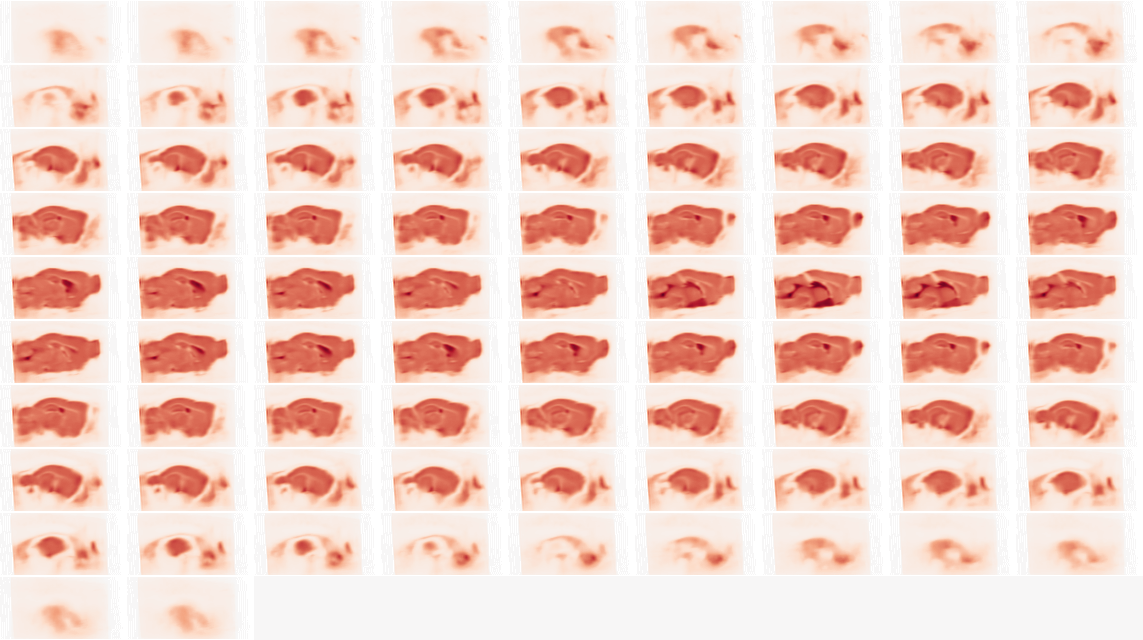

In [8]:
# plot the anatomical image interactively and scroll through it (HINT THIS IS MOUSE DATA so set the bg_img to False otherwise you will see a human brain)
plotting.view_img(anat_img, bg_img = False)


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipython-input-14-3494046452.py:2: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  plotting.view_img(bold_img.slicer[...,0], bg_img = anat_img, cmap = 'Greys_r', threshold = 0)



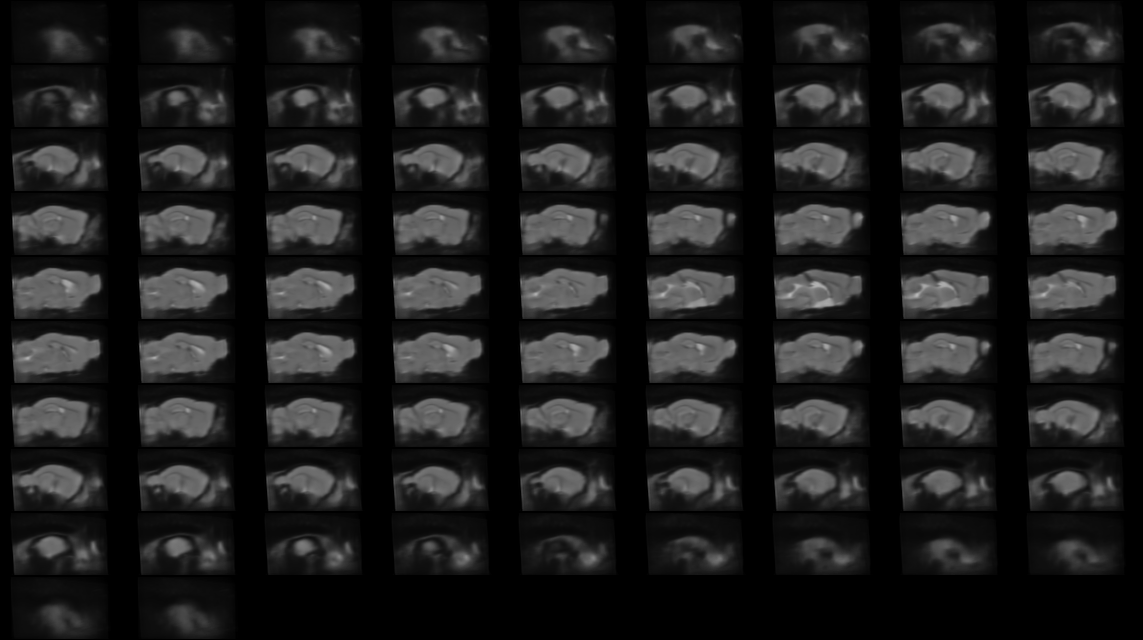
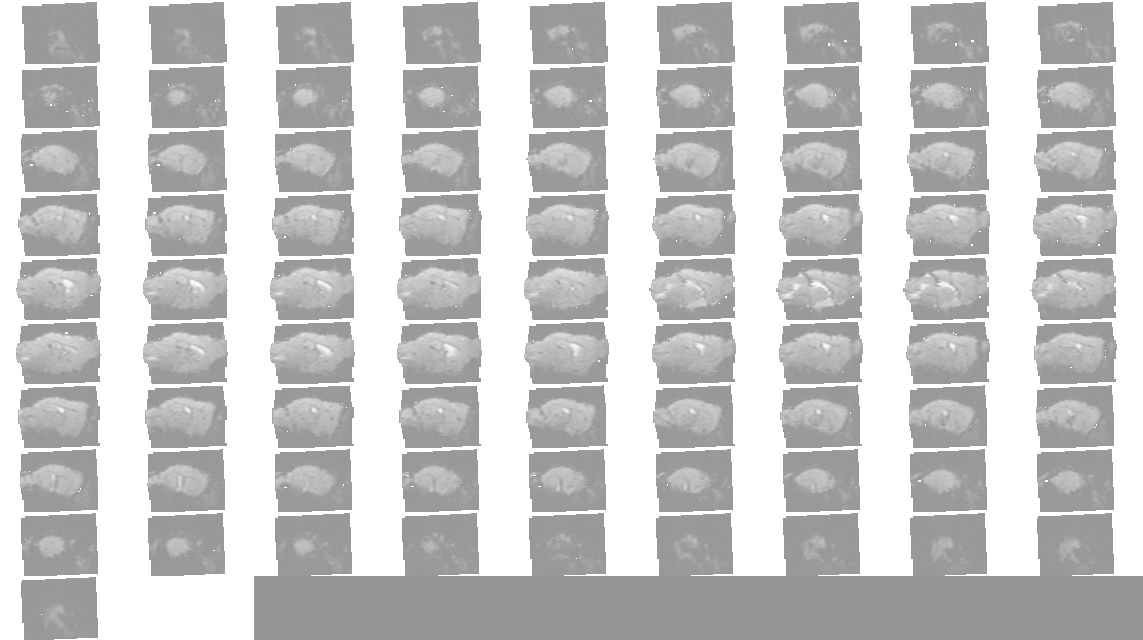

In [ ]:
# can you plot the bold scan interactively?
plotting.view_img(bold_img.slicer[...,0], bg_img = anat_img, cmap = 'Greys_r', threshold = 0)

## 3.3.3

In [ ]:
from nilearn.masking import apply_mask

# drop the first 10 timepoints from the bold scan
bold_img_dropstart = bold_img.slicer[...,10:]

# apply the mask to the resulting bold scan

bold_img_dropstart_masked = apply_mask(bold_img_dropstart, bold_mask)

# how many voxels are inside the brain and how many are outside the brain? (hint: compare the dimensions of the original and masked image)
print(bold_img_dropstart.shape)
print(bold_img_dropstart_masked.shape)


(62, 95, 48, 170)
(170, 49255)


In [ ]:
print(f'So the original scan has {62*95*49} voxels and the masked scan has {bold_img_dropstart_masked.shape[1]} voxels, thats a ratio of {bold_img_dropstart_masked.shape[1]/(62*95*49)}')

So the original scan has 288610 voxels and the masked scan has 49255 voxels, thats a ratio of 0.1706628321956966


(170,)


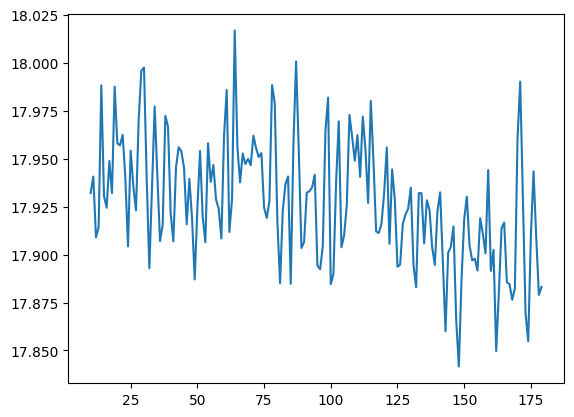

In [ ]:
# compute the average timecourse within the brain aka the global signal timecourse (hint use the output from the previous step and basic python tools for working with arrays that you learned in previous lectures)
global_signal = np.mean(bold_img_dropstart_masked, axis = 1)
print(global_signal.shape)

# plot the global signal timecourse with time on the x-axis (remember that you dropped the first 10 timepoints!)
time_axis = np.arange(10, global_signal.shape[0]+10, 1)
plt.plot(time_axis, global_signal)

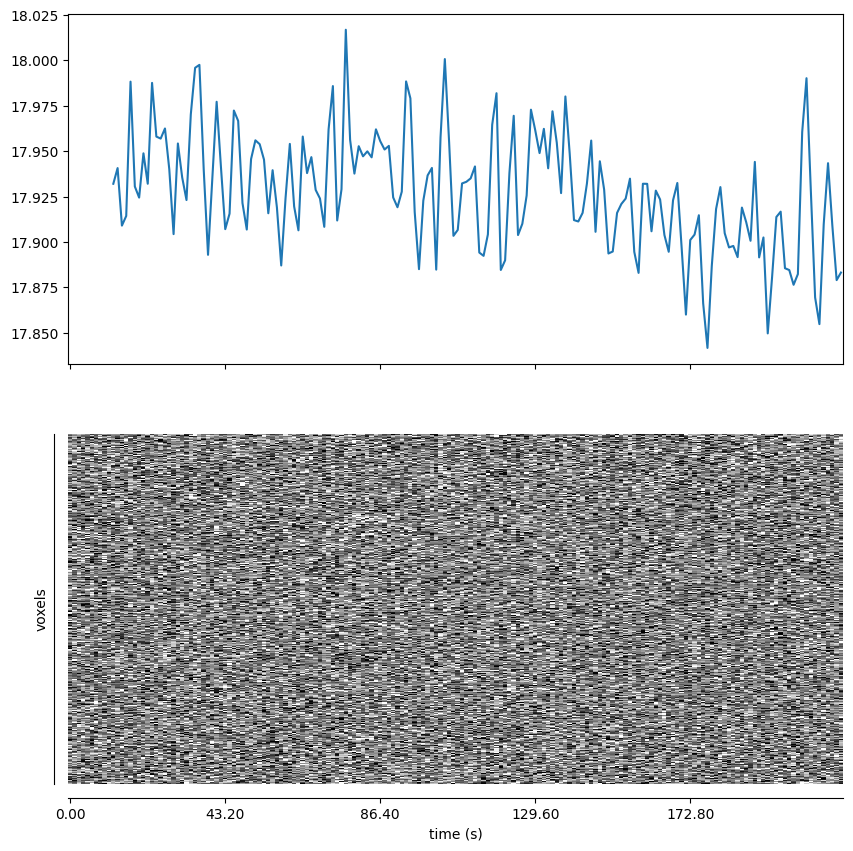

In [ ]:
### ADVANCED ###
# plot the carpet plot by checking the arguments of nilearn's plot_carpet function on your own and plot also the global signal timecourse above it such that the x-axes are aligned
# hint: the carpet plot function has an axes argument
fig, ax = plt.subplots(2,1, figsize=(10, 10), sharex = True)
ax[0].plot(np.arange(10, global_signal.shape[0]+10, 1), global_signal)
carpet = plotting.plot_carpet(bold_img, mask_img = bold_mask, standardize="zscore_sample", axes=ax[1])
plt.show()

## 3.3.4

In [ ]:
# clean your image to : standardize, filter between 0.01 and 0.1Hz and regress the global signal.
# the TR of this dataset is 1.2s
clean_img = nli.clean_img(bold_img_dropstart,
                          confounds=global_signal,
                          detrend=True,standardize=True,
                          low_pass=0.1,high_pass=0.01,  #filter frequencies within range of expected signal
                          t_r=1.2, #include the TR of the data
                          mask_img=bold_mask) #only clean the voxels within the mask

/tmp/ipython-input-32-1200974525.py:2: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_img = nli.clean_img(bold_img_dropstart,


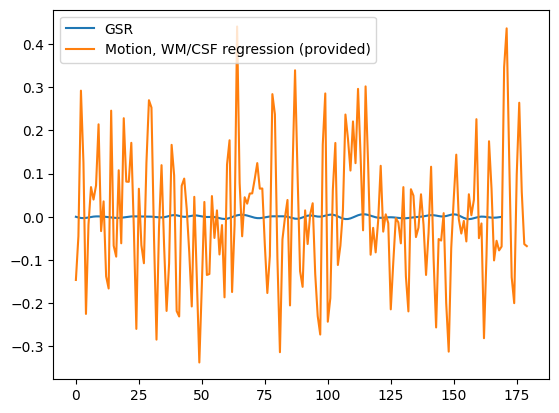

In [ ]:
# compare the global timeseries of the resulting clean_img as well as the file that I provided called bold_img_clean (this was cleaned with motion and WM/CSF regression)
global_signal_clean_mine = np.mean(apply_mask(clean_img, bold_mask), axis = 1)
global_signal_clean_provided = np.mean(apply_mask(bold_img_clean, bold_mask), axis = 1)

plt.plot(global_signal_clean_mine, label = 'GSR')
plt.plot(global_signal_clean_provided, label = 'Motion, WM/CSF regression (provided)')
plt.legend()

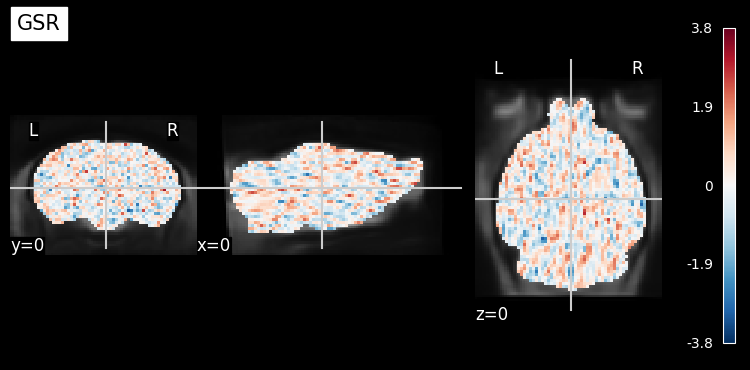

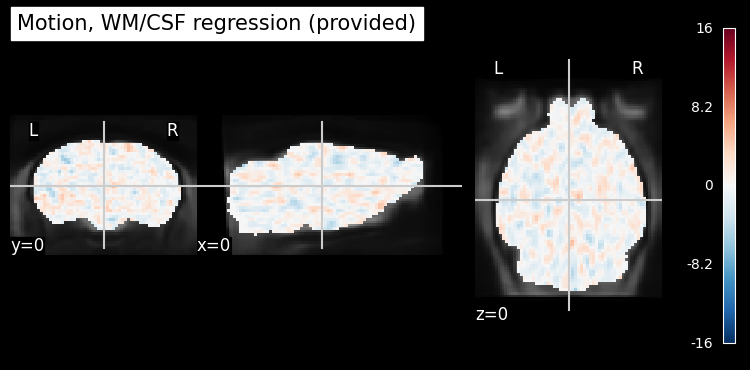

In [ ]:
# plot a single timepoint from the two images using plot stat_map (the one you regressed global signal from and the provided cleaned image)
plotting.plot_stat_map(clean_img.slicer[...,80], bg_img = anat_img, title = 'GSR')
plotting.plot_stat_map(bold_img_clean.slicer[...,80], bg_img = anat_img, title = 'Motion, WM/CSF regression (provided)')

In [ ]:
##$ ADVANCED ###

# perform ICA with 5 components. Do this 3 times - on the raw data, on the data that you cleaned with global signal regression, and on the cleaned provided data

In [ ]:
# Import CanICA module
from nilearn.decomposition import CanICA

# Specify relevant parameters
n_components = 5
fwhm = 0.3

# Specify CanICA object
canica = CanICA(mask = bold_mask, #only compute components within the brain
                n_components=n_components, #the number of ICA components to derive - check the literature for relevant values
                smoothing_fwhm=fwhm, #size of smoothing kernel in mm
                memory="nilearn_cache", memory_level=2,
                threshold='auto', verbose=10, random_state=0, n_jobs=-1,
                standardize=True)

### the raw data without cleaning

[CanICA.fit] loading mask from Nifti1Image('sub-001_task-rest_boldmask.nii.gz')

[CanICA.fit] Resampling mask

[CanICA.fit] Loading data

________________________________________________________________________________
[Memory] Calling sklearn.utils.extmath.randomized_svd...
randomized_svd(array([[ 0.002039, ..., -0.007004],
       ...,
       [-0.003022, ..., -0.00671 ]]), n_components=5, transpose=True, random_state=0, n_iter=3)
___________________________________________________randomized_svd - 0.2s, 0.0min


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    1.9s finished


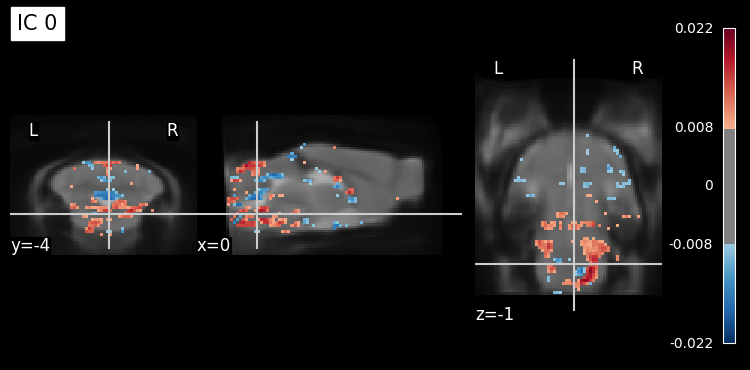

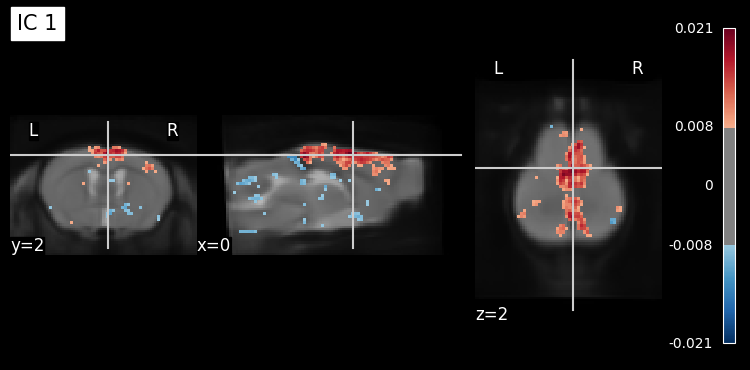

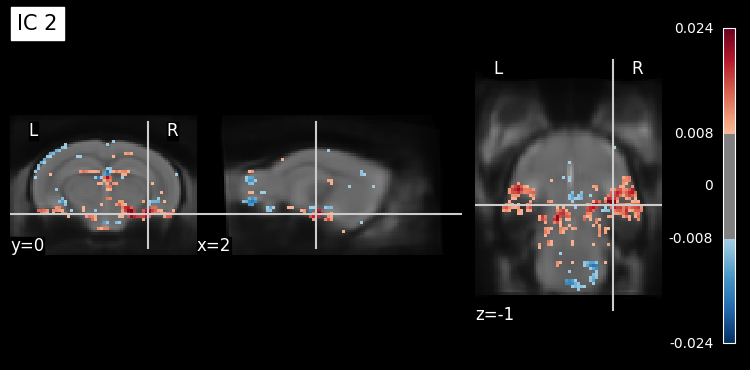

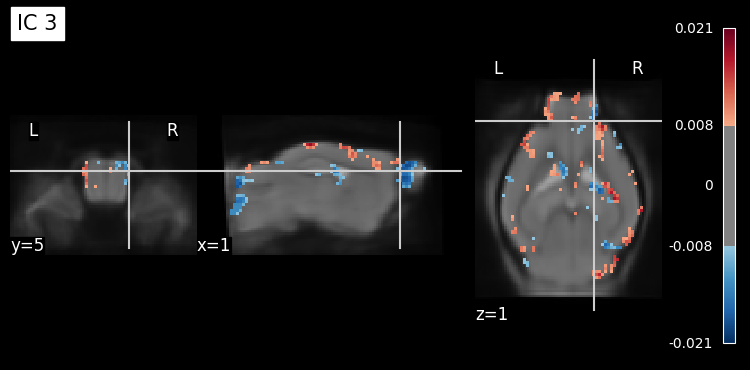

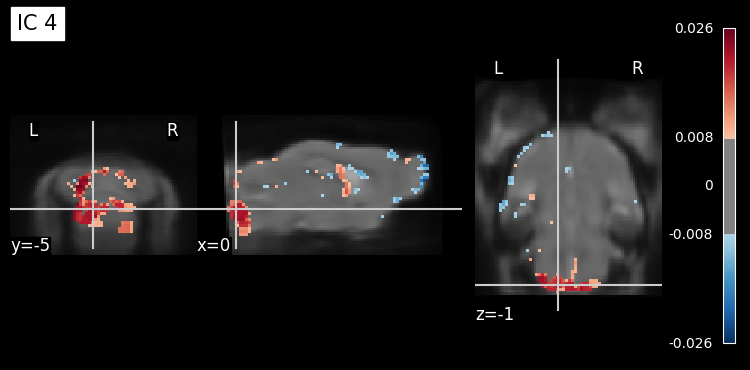

In [ ]:
# Run/fit CanICA on input data
canica.fit(bold_img)

# Retrieve the independent components in brain space
components_img = canica.masker_.inverse_transform(canica.components_)

for i, cur_img in enumerate(nli.iter_img(components_img)):
    plotting.plot_stat_map(cur_img, display_mode="ortho", title="IC %d" % i,
                            colorbar=True, bg_img=anat_img, threshold = 0.008)

### The global signal regression

[CanICA.fit] loading mask from Nifti1Image('sub-001_task-rest_boldmask.nii.gz')

[CanICA.fit] Resampling mask

[Memory]21.6s, 0.4min   : Loading resample_img from nilearn_cache/joblib/nilearn/image/resampling/resample_img/646f34349a95acf28a2f7b987a5b9eb3
________________________________________resample_img cache loaded - 0.0s, 0.0min


[CanICA.fit] Loading data

________________________________________________________________________________
[Memory] Calling sklearn.utils.extmath.randomized_svd...
randomized_svd(array([[ 0.005359, ...,  0.005936],
       ...,
       [-0.000946, ..., -0.000114]]), n_components=5, transpose=True, random_state=0, n_iter=3)
___________________________________________________randomized_svd - 0.2s, 0.0min
________________________________________________________________________________
[Memory] Calling nilearn.masking.unmask...
unmask(array([[ 6.027400e-03, ..., -1.384709e-03],
       ...,
       [-3.473992e-03, ...,  4.131821e-05]]), 
<nibabel.nifti1.Nifti1Image object at 0x7a49b3f1d710>)
___________________________________________________________unmask - 0.3s, 0.0min


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    3.4s finished


________________________________________________________________________________
[Memory] Calling nilearn.masking.unmask...
unmask(array([[-0.      , ...,  0.007612],
       ...,
       [ 0.      , ...,  0.      ]]), 
<nibabel.nifti1.Nifti1Image object at 0x7a49b3f1d710>)
___________________________________________________________unmask - 0.3s, 0.0min
[Memory]36.3s, 0.6min   : Loading unmask from nilearn_cache/joblib/nilearn/masking/unmask/6c52a96ef4b2a741398192850b3595e0
______________________________________________unmask cache loaded - 0.0s, 0.0min


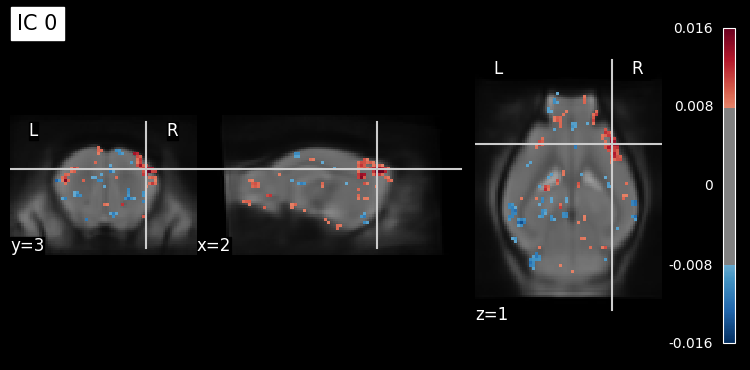

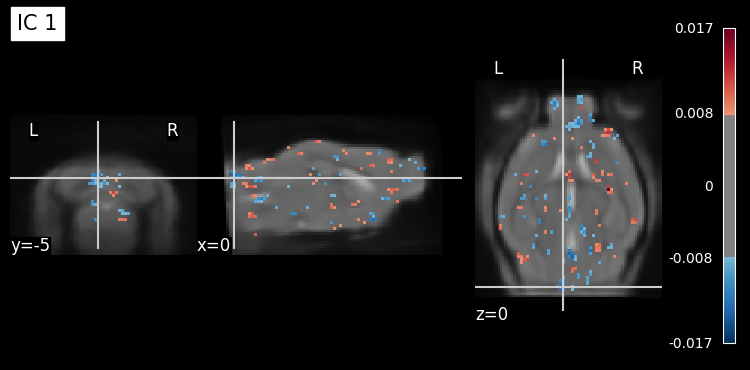

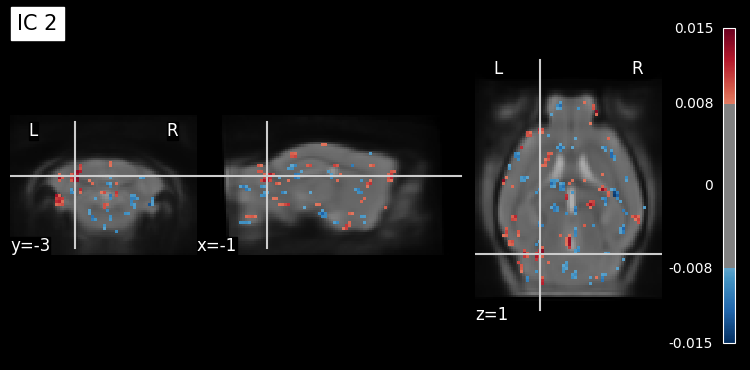

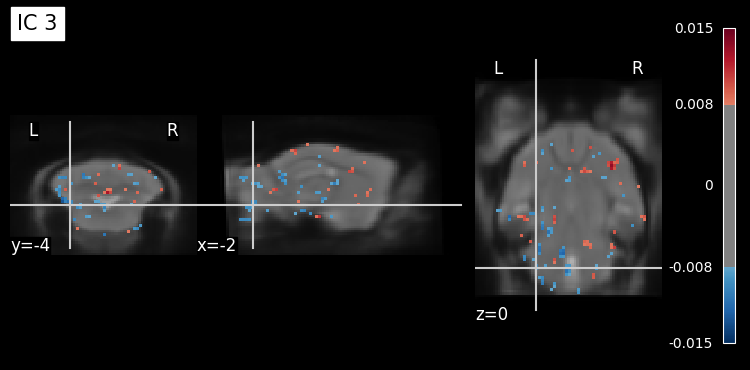

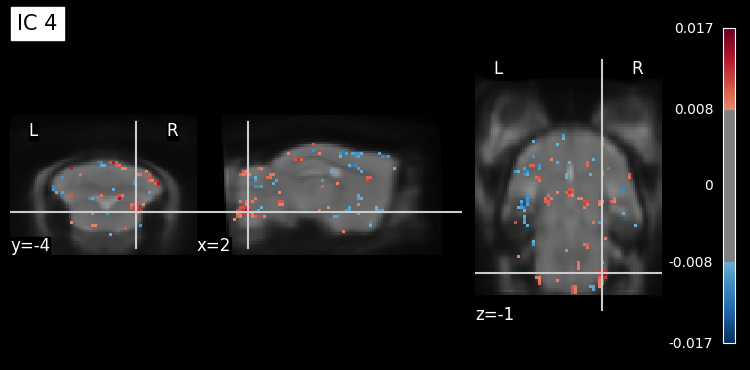

In [ ]:
# Run/fit CanICA on input data
canica.fit(clean_img)

# Retrieve the independent components in brain space
components_img = canica.masker_.inverse_transform(canica.components_)

for i, cur_img in enumerate(nli.iter_img(components_img)):
    plotting.plot_stat_map(cur_img, display_mode="ortho", title="IC %d" % i,
                            colorbar=True, bg_img=anat_img, threshold = 0.008)

### The provided cleaned data

[CanICA.fit] loading mask from Nifti1Image('sub-001_task-rest_boldmask.nii.gz')

[CanICA.fit] Resampling mask

[Memory]53.1s, 0.9min   : Loading resample_img from nilearn_cache/joblib/nilearn/image/resampling/resample_img/646f34349a95acf28a2f7b987a5b9eb3
________________________________________resample_img cache loaded - 0.0s, 0.0min


[CanICA.fit] Loading data

________________________________________________________________________________
[Memory] Calling sklearn.utils.extmath.randomized_svd...
randomized_svd(array([[-0.001968, ..., -0.009032],
       ...,
       [-0.003729, ..., -0.008599]]), n_components=5, transpose=True, random_state=0, n_iter=3)
___________________________________________________randomized_svd - 0.1s, 0.0min
________________________________________________________________________________
[Memory] Calling nilearn.masking.unmask...
unmask(array([[-0.007356, ..., -0.006385],
       ...,
       [ 0.004455, ...,  0.009286]]), 
<nibabel.nifti1.Nifti1Image object at 0x7a49b3f900d0>)
___________________________________________________________unmask - 0.3s, 0.0min


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    6.2s finished


________________________________________________________________________________
[Memory] Calling nilearn.masking.unmask...
unmask(array([[-0.      , ..., -0.      ],
       ...,
       [-0.005406, ..., -0.005449]]), 
<nibabel.nifti1.Nifti1Image object at 0x7a49b3f900d0>)
___________________________________________________________unmask - 0.3s, 0.0min
[Memory]69.0s, 1.1min   : Loading unmask from nilearn_cache/joblib/nilearn/masking/unmask/d3a6042cd5564d96997ecfd2b27b12a2
______________________________________________unmask cache loaded - 0.0s, 0.0min


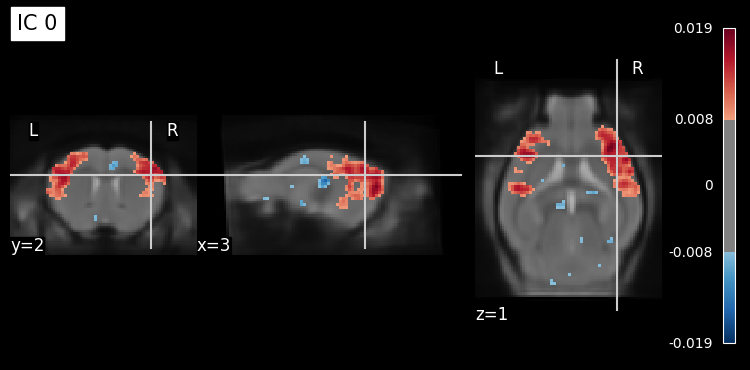

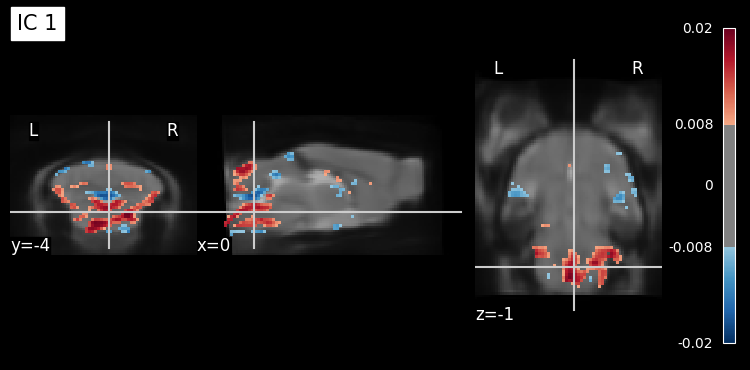

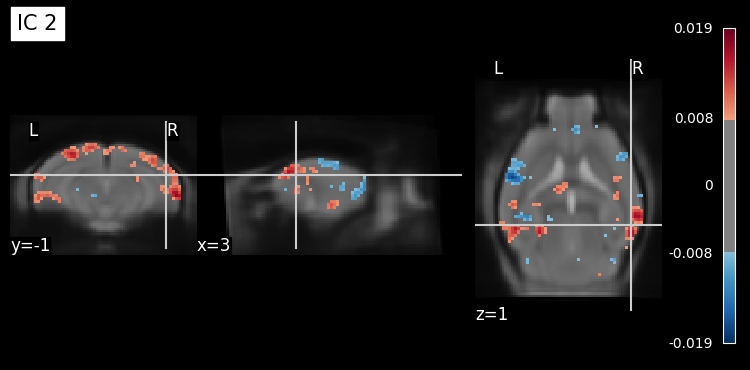

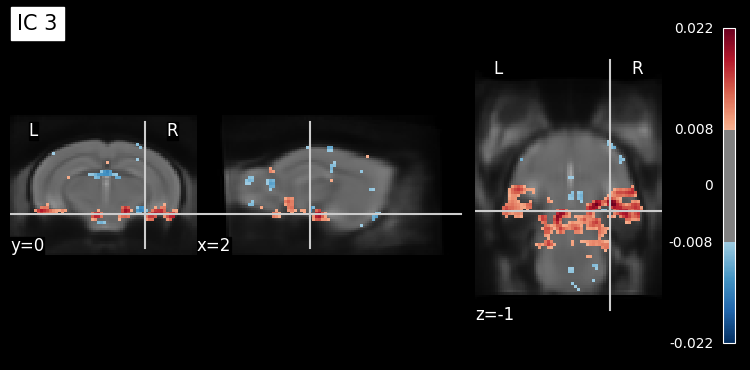

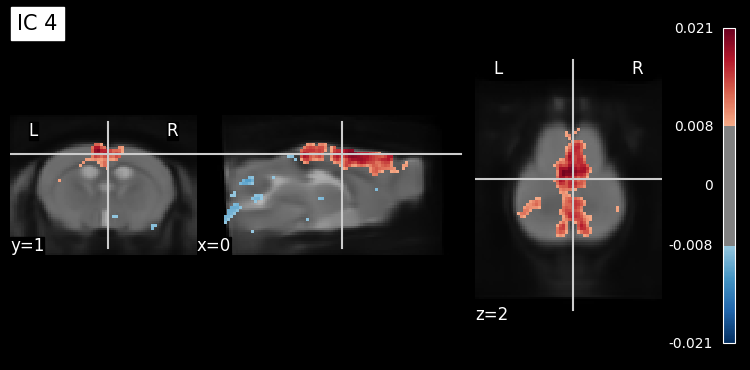

In [ ]:
# Run/fit CanICA on input data
canica.fit(bold_img_clean)

# Retrieve the independent components in brain space
components_img = canica.masker_.inverse_transform(canica.components_)

for i, cur_img in enumerate(nli.iter_img(components_img)):
    plotting.plot_stat_map(cur_img, display_mode="ortho", title="IC %d" % i,
                            colorbar=True, bg_img=anat_img, threshold = 0.008)